# Import

In [423]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

import networkx as nx
import numpy as np

import copy


from shapely.geometry import Polygon

import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER



# Data exploration of the conflict data

* Goal is to do some graphs to elaborate on the cooccurance of mines and conflicts


## Transformations

In [5]:
cf = pd.read_excel('data\EJAtlas_dataset_V1_2024-01.xlsx', sheet_name='EJAtlas Data', skiprows=[0])


In [6]:
cf.head()

,Conflict Id,Country,Case,Site,Province,Lon,Lat,Accuracy of location,Description,Project Details,...,SecImpact: Land dispossession,SecImpact: Loss of landscape/sense of place,SecImpact: Other socio-economic impacts,Other Sec Impacts,References,Legislations,Weblinks,Medialinks,Created At,Modified At
0,3,Germany,"Stuttgart 21 Project, Germany",Stuttgart,Baden-Württemberg,9.19735908508301,48.7964046844567,HIGH local level,<p>Stuttgart 21 is a railway and urban develop...,33 kilometers of additional tunnels.\n25 kilom...,...,0,P,0,NaN,NaN,NaN,http://goo.gl/OXBCu4\n\nArticles in the Englis...,Euronews europeans: Stuttgart 21: dividing a c...,2014-03-11 19:18:02 UTC,2015-01-26 09:05:48 UTC
1,4,United Kingdom,"High Speed Two railway, United Kingdom",Several (Railway),"London, East Midlands, West Midlands",-0.10986328125,51.4882243263235,LOW country/state level,<p>High Speed 2 (HS2) is a planned high-speed ...,Width: 72 m Speed: 400 kph,...,P,P,0,NaN,Department for Transport (2013). High Speed 2:...,EU Directive 96/48/EC,HS2 Project web page:\nhttp://www.hs2.org.uk/\...,BBC Countryfile report on HS2 threat to Chilte...,2014-03-11 19:18:03 UTC,2014-04-08 15:06:33 UTC
2,5,France,"Nice - OIN plaine du Var, France",Nice,Provence-Alpes Cote dAzur,7.24239349365234,43.7108197524576,MEDIUM regional level,<p>The OIN (Operation d Intérêt National) Eco-...,Construction of Olympic Nice Stadium.\nIkea st...,...,P,P,0,NaN,An article with a positive view of the project...,Décret n° 2008-773 du 30 juillet 2008 portant ...,Another website promoting the project:\nhttp:/...,Videos of the actions carried out by the oppos...,2014-03-11 19:18:03 UTC,2014-04-08 15:04:04 UTC
3,6,Germany,"Fehmarn Belt Fixed Link, Germany - Denmark",Ostholstein/ Lolland,Schleswig-Holstein/ Region Zealand,11.2898254394531,54.5771678087124,MEDIUM regional level,<p>The Fehmarn Belt Fixed Link is an immersed ...,"17.6 km of immersed tunnel: 40 m wide, almost ...",...,0,0,0,NaN,Fixed Link (2009). Fehmarn Belt. Review of a f...,NaN,NABU analysis of economic concerns and environ...,Fehmarn Belt Fixed Link - bridge between Denma...,2014-03-11 19:18:04 UTC,2014-06-24 07:42:52 UTC
4,7,Spain,"Trans-Pyrenean Central Corridor, Spain - France",NaN,"Aragon (Spain), Midi-Pyrénées (France )",-0.2032470703125,42.7991771735111,MEDIUM regional level,<p>The Trans-Pyrenean Central Corridor (TCP in...,Several tunnels. The longest could be of about...,...,0,P,0,NaN,"Article supporting the project:\n\n\nVal, S. a...",Proposal for a REGULATION OF THE EUROPEAN PARL...,French association defending the project (in F...,Actival association website (in French)\nhttp:...,2014-03-11 19:18:04 UTC,2015-01-26 09:04:15 UTC


filter for all cases that contain the words mining.

Therefore i query for

col_int = ['Type: Uranium extraction', 
           'Type: Mineral ore exploration',
           'Type: Mineral processing',
           'Type: Tailings from mines',
           'Type: Landfills, toxic waste treatment, uncontrolled dump sites'
]


i leaf the Metal refinieries out as the scope of teh work is extraction

In [16]:
cf.columns

Index(['Conflict Id', 'Country', 'Case', 'Site', 'Province', 'Lon', 'Lat',
       'Accuracy of location', 'Description', 'Project Details',
       ...
       'SecImpact: Land dispossession',
       'SecImpact: Loss of landscape/sense of place',
       'SecImpact: Other socio-economic impacts', 'Other Sec Impacts',
       'References', 'Legislations', 'Weblinks', 'Medialinks', 'Created At',
       'Modified At'],
      dtype='object', length=263)

In [31]:
col_int = ['Type: Uranium extraction', 
           'Type: Mineral ore exploration',
           'Type: Mineral processing',
           'Type: Tailings from mines',
           'Type: Landfills, toxic waste treatment, uncontrolled dump sites'    
           ]

mask = cf[col_int].eq(1).any(axis=1)

In [32]:
cfm = cf[mask]

In [35]:
cfm.shape[0] /cf.shape[0]

0.2851592851592852

In the Subset we have 1101 mining related conflicts. this are approx 30\% of all conflicts. Roughly the amount mentioned in the paper Lets fix the long lat of the subset

Transformation: The rstrip() method removes any trailing characters (characters at the end a string), space is the default trailing character to remove.

Striped the . at the end.


In [43]:
cfm['Lon'] = cfm['Lon'].astype(str).str.rstrip('.')
cfm['Lat'] = cfm['Lat'].astype(str).str.rstrip('.')
cfm[['Lon', 'Lat']] = cfm[['Lon', 'Lat']].astype(float)


C:\Users\admin\AppData\Local\Temp\ipykernel_11232\501545020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cfm['Lon'] = cfm['Lon'].astype(str).str.rstrip('.')
C:\Users\admin\AppData\Local\Temp\ipykernel_11232\501545020.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cfm['Lat'] = cfm['Lat'].astype(str).str.rstrip('.')
C:\Users\admin\AppData\Local\Temp\ipykernel_11232\501545020.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

<Axes: xlabel='Lon', ylabel='Lat'>

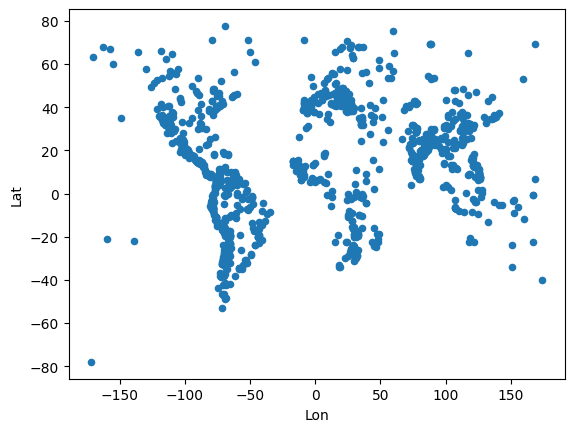

In [44]:
cfm.plot.scatter(x='Lon', y='Lat')

In [48]:
cg = gpd.GeoDataFrame(cfm, geometry=gpd.points_from_xy(cfm.Lon, cfm.Lat))

## Analysis of spatial density of conflicts

<Axes: >

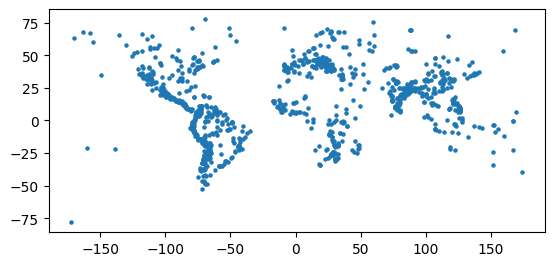

In [52]:
cg.plot(markersize=5)

<Axes: xlabel='Lon', ylabel='Lat'>

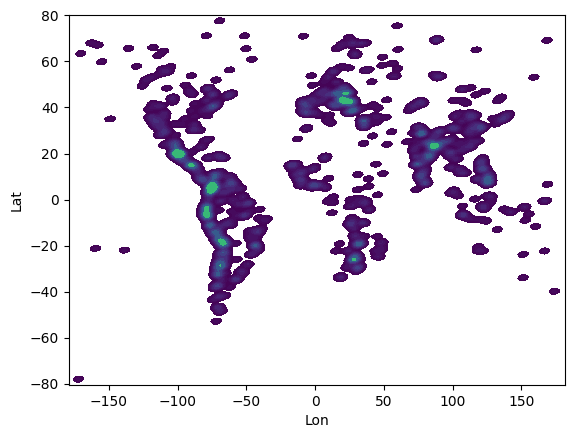

In [60]:
sns.kdeplot(x=cg['Lon'], y=cg['Lat'], cmap='viridis', fill=True, bw_adjust=.1)

## Discussion map building

* mining polygons
* conflict
* mine centroids + buffer

do two bounding boxes around focus areas

In [97]:
poly = gpd.read_file('data\mine-comm\global_mining_land_use_comm.gpkg')

In [98]:
poly_m = poly.to_crs('EPSG:3857')

In [99]:
poly_m['buf_50km'] = poly_m.centroid.buffer(5*10**4)

<Axes: >

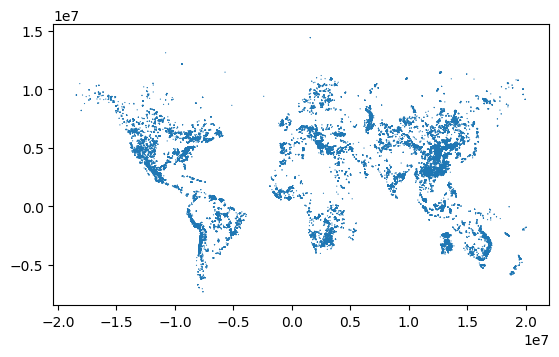

In [100]:
poly_m.buf_50km.plot()

In [101]:
poly_trans = poly_m.to_crs('EPSG:4326')

<Axes: >

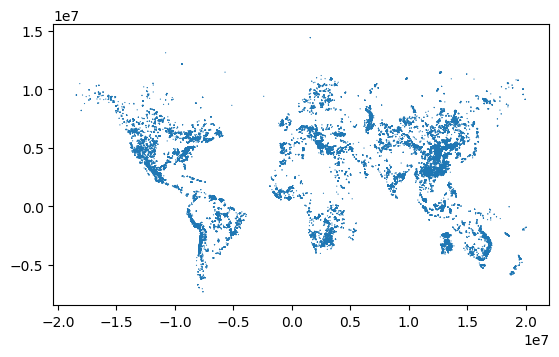

In [102]:
poly_trans['buf_50km'].plot()

In [111]:
cg.set_crs('EPSG:4326', inplace=True)

,Conflict Id,Country,Case,Site,Province,Lon,Lat,Accuracy of location,Description,Project Details,...,SecImpact: Loss of landscape/sense of place,SecImpact: Other socio-economic impacts,Other Sec Impacts,References,Legislations,Weblinks,Medialinks,Created At,Modified At,geometry
14,19,United States of America,Emelle nation's largest hazardous waste landfi...,Emelle (Sumter County),Alabama,-88.308805,32.796690,HIGH local level,"<p>In 1978, Chemical Waste Management, a subsi...","At its peak, the company received almost 800,0...",...,0,0,NaN,"Bullard, Robert D., and Beverly H. Wright. ""Th...",EPA's Hazardous Waste Facility Permit\nhttp://...,University of Michigan's Environmental Justice...,NaN,2014-03-11 19:18:10 UTC,2015-07-08 09:47:03 UTC,POINT (-88.30881 32.79669)
15,20,United States of America,"PCB Contamination in Warren County, USA",Warren County,North Carolina,-78.173911,36.336907,MEDIUM regional level,<p>Warren County was one of the first cases of...,"40,000 cubic yards of PCB contaminated soil",...,P,0,NaN,"Cutter, Susan L. ""Race, class and environmenta...",NaN,Environmental Injustice in North Caroline\nhtt...,Image from Ricky Stillely Photography and the ...,2014-03-11 19:18:11 UTC,2015-07-08 09:49:35 UTC,POINT (-78.17391 36.33691)
18,23,United States of America,"Toxic Waste Landfill in Kettleman City, Calif....",Kettleman City,California,-119.963690,35.998650,HIGH local level,<p>Kings County is a county in California’s Sa...,Chemical waste disposal and treatment site wit...,...,0,0,NaN,NaN,NaN,"2,- The Kettelman Hills Facility - the company...",Youtube Video: Birth defects linked to polluti...,2014-03-11 19:18:12 UTC,2023-08-16 11:19:24 UTC,POINT (-119.96369 35.99865)
19,24,United States of America,"Clustering of Waste Facilities in Chester, USA",Chester,Pennsylvania,-75.405589,39.825152,MEDIUM regional level,"<p>Chester, a city located within Delaware Cou...",Westinghouse Resource Recovery Facility burns ...,...,0,0,NaN,"'Laid to Waste', by Robert Bahar and George Mc...",Court Case 'Chester Residents Concerned for Qu...,'Environmental Racism in Chester' by Mike Ewal...,"Chester Environmental Justice, It contains por...",2014-03-11 19:18:12 UTC,2015-07-08 09:48:45 UTC,POINT (-75.40559 39.82515)
23,28,Tanzania,"Soda ash mining in Lake Natron, Tanzania",Arusha District,Northern Tanzania,36.135653,-2.283979,MEDIUM regional level,"<p>Lake Natron Resources Limited, a company jo...",The company plans to produce 0.5 million tonne...,...,0,0,loss of revenue from tourism,NaN,The Constitution of the United Republic of Tan...,(2)\nhttp://www.unpo.org/article/13509\n\nFact...,NaN,2014-03-11 19:18:15 UTC,2014-04-08 15:06:37 UTC,POINT (36.13565 -2.28398)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3847,6371,Greenland,Black Angel zinc-lead mine since 1972. Greenland,Maamorilik,Avannaata,-51.273300,71.122400,HIGH local level,<p>Danish geologists started to explore The Bl...,Size of he mine: 5 sq km (500 hectares). The P...,...,0,0,NaN,"[2] Sörlin, S., Dale, B., Keeling, A., Larsen,...","[7] Answer to Enquiry, Requested by: Rebecca W...",[3] Wikimapia: Black Angel Lead/Zinc Mine\nhtt...,NaN,2023-06-26 20:46:21 UTC,2023-07-30 06:24:15 UTC,POINT (-51.27330 71.12240)
3850,6376,Chile,"Minería de Tierras Raras en Penco, Región del ...",Penco,"Provincia de Concepción, Región Bio-Bío",-72.962500,-36.735000,MEDIUM regional level,"<p>Desde 2015, en los cerros de la ciudad de P...","Inicialmente, el proyecto de la empresa chilen...",...,P,0,NaN,NaN,NaN,[3]OCMAL . Conflicto Minero: Comunidad de Penc...,17 - Parque para Penco\nhttps://www.instagram....,2023-07-11 22:26:25 UTC,2023-07-11 22:26:25 UTC,POINT (-72.96250 -36.73500)
3853,6385,Madagascar,"Maniry graphite project in Ambohitsy Haut, Mad...",Ambohitsy Haut,Toliara,44.816677,-24.499940,MEDIUM regional level,"<p>Australian mining company Evion, formerly k...",- The mine's projected lifespan is 21 years [9...,...,P,0,Desecration of tombs,NaN,NaN,[

In [107]:
poly_m.set_index('row.id', inplace=True)

KeyError: "None of ['row.id'] are in the columns"

In [108]:
poly_m

,area,admin,adm0_a3,list_of_commodities,geometry,buf_50km
row.id,,,,,,
1,0.038096,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((19087285.169 -5226968.049, 190...","POLYGON ((19137298.168 -5227208.984, 19137057...."
2,0.114247,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((19067292.189 -5226485.372, 190...","POLYGON ((19117219.375 -5226688.032, 19116978...."
3,0.125528,New Zealand,NZL,"Molybdenum,Tin,Silver,Gold","MULTIPOLYGON (((19021695.725 -5290519.589, 190...","POLYGON ((19071446.837 -5290576.631, 19071206...."
4,0.288590,New Zealand,NZL,Coal,"MULTIPOLYGON (((18702743.120 -5773509.154, 187...","POLYGON ((18752847.566 -5773769.063, 18752606...."
5,0.349819,New Zealand,NZL,Coal,"MULTIPOLYGON (((18689039.691 -5763826.743, 186...","POLYGON ((18739407.872 -5764273.104, 18739167...."
...,...,...,...,...,...,...
81558,0.055417,China,CHN,None,"MULTIPOLYGON (((12348122.854 5028774.758, 1234...","POLYGON ((12397940.615 5028738.683, 12397699.8..."
81559,0.034229,China,CHN,None,"MULTIPOLYGON (((12346584.096 5028356.281, 1234...","POLYGON ((12396443.887 5028311.265, 12396203.1..."
81560,0.031565,China,CHN,None,"MULTIPOLYGON (((12346694.124 5027979.011, 1234...","POLYGON ((12396576.757 5027940.045, 12396335.9..."


In [117]:
ptrans = poly_m.set_geometry('buf_50km').to_crs('EPSG:4326')

In [118]:
ptrans.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [119]:
# Perform spatial join with the subset dataframe
polcon50 = ptrans.sjoin(cg, how='inner')


In [120]:
polcon50.head()

,area,admin,adm0_a3,list_of_commodities,geometry,buf_50km,index_right,Conflict Id,Country,Case,...,SecImpact: Land dispossession,SecImpact: Loss of landscape/sense of place,SecImpact: Other socio-economic impacts,Other Sec Impacts,References,Legislations,Weblinks,Medialinks,Created At,Modified At
row.id,,,,,,,,,,,,,,,,,,,,,
73,2.051102,Argentina,ARG,"Gold,Silver,Lead,Zinc","MULTIPOLYGON (((-69.49830 -48.77840, -69.49710...","POLYGON ((-69.03776 -48.77587, -69.03992 -48.8...",571,733,Argentina,"Manantial Espejo, gold and silver mining, Sant...",...,0,P,0,NaN,Observatorio de Conflictos Mineros de America ...,NaN,"""Mueren dos jóvenes operarios en accidente en ...","Video ""Manantial Espejo, una mina por dentro""....",2014-03-11 19:26:18 UTC,2020-01-11 14:53:45 UTC
74,0.040568,Argentina,ARG,"Gold,Silver,Lead,Zinc","MULTIPOLYGON (((-69.47550 -48.78930, -69.47510...","POLYGON ((-69.02587 -48.78871, -69.02803 -48.8...",571,733,Argentina,"Manantial Espejo, gold and silver mining, Sant...",...,0,P,0,NaN,Observatorio de Conflictos Mineros de America ...,NaN,"""Mueren dos jóvenes operarios en accidente en ...","Video ""Manantial Espejo, una mina por dentro""....",2014-03-11 19:26:18 UTC,2020-01-11 14:53:45 UTC
75,0.335809,Argentina,ARG,"Gold,Silver,Lead,Zinc","MULTIPOLYGON (((-69.51450 -48.79370, -69.51520...","POLYGON ((-69.06092 -48.79688, -69.06308 -48.8...",571,733,Argentina,"Manantial Espejo, gold and silver mining, Sant...",...,0,P,0,NaN,Observatorio de Conflictos Mineros de America ...,NaN,"""Mueren dos jóvenes operarios en accidente en ...","Video ""Manantial Espejo, una mina por dentro""....",2014-03-11 19:26:18 UTC,2020-01-11 14:53:45 UTC
76,1.123157,Argentina,ARG,"Gold,Silver,Lead,Zinc","MULTIPOLYGON (((-69.49990 -48.79360, -69.50020...","POLYGON ((-69.04256 -48.79538, -69.04472 -48.8...",571,733,Argentina,"Manantial Espejo, gold and silver mining, Sant...",...,0,P,0,NaN,Observatorio de Conflictos Mineros de America ...,NaN,"""Mueren dos jóvenes operarios en accidente en ...","Video ""Manantial Espejo, una mina por dentro""....",2014-03-11 19:26:18 UTC,2020-01-11 14:53:45 UTC
77,0.018552,Argentina,ARG,"Gold,Silver,Lead,Zinc","MULTIPOLYGON (((-69.57850 -48.84420, -69.57880...","POLYGON ((-69.12874 -48.84507, -69.13090 -48.8...",571,733,Argentina,"Manantial Espejo, gold and silver mining, Sant...",...,0,P,0,NaN,Observatorio de Conflictos Mineros de America ...,NaN,"""Mueren dos jóvenes operarios en accidente en ...","Video ""Manantial Espejo, una mina por dentro""....",2014-03-11 19:26:18 UTC,2020-01-11 14:53:45 UTC


In [160]:
gr = polcon50.groupby('row.id')['Conflict Id'].count().reset_index()

In [161]:
gr.rename(columns={'Conflict Id': 'conflicts'}, inplace=True)

In [162]:
gr.head()

,row.id,conflicts
0,73,1
1,74,1
2,75,1
3,76,1
4,77,1


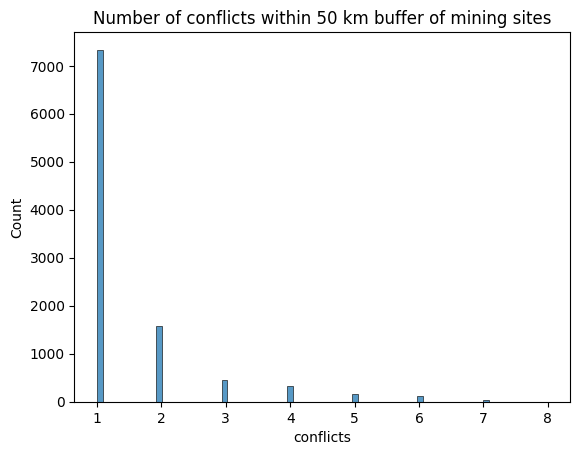

In [231]:
sns.histplot(data = gr['conflicts'])

plt.title('Number of conflicts within 50 km buffer of mining sites')

plt.savefig('fig/conf_per_mine_50k.png')

In [171]:
polcon50['mine_id'] =polcon50.index

In [172]:
cpm = polcon50.groupby('Conflict Id')['mine_id'].count().reset_index()

In [174]:
cpmplot = cpm.rename(columns={'mine_id': 'mines'})

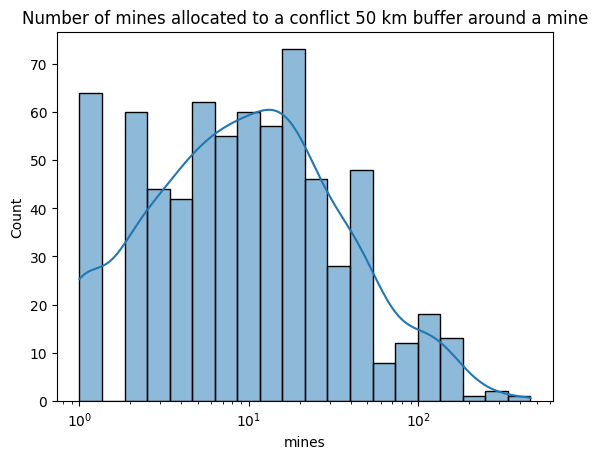

In [232]:
sns.histplot(data = cpmplot.mines, bins=20, log_scale=True, kde = True)

plt.title('Number of mines allocated to a conflict 50 km buffer around a mine')
plt.savefig('fig/mine_per_con.png')

In [186]:
sub = polcon50['Conflict Id']

In [193]:
sub.rename('conflict_id', inplace=True)

row.id
73        733
74        733
75        733
76        733
77        733
         ... 
81423    2920
81430    4395
81431    4395
81432    3814
81433    3814
Name: conflict_id, Length: 15081, dtype: int64

In [195]:
coo = pd.crosstab(sub.index, sub.values)

In [223]:
ad = coo.dot(coo.T)

In [224]:
np.fill_diagonal(ad.values, 0)

In [226]:
G = nx.from_pandas_adjacency(ad)

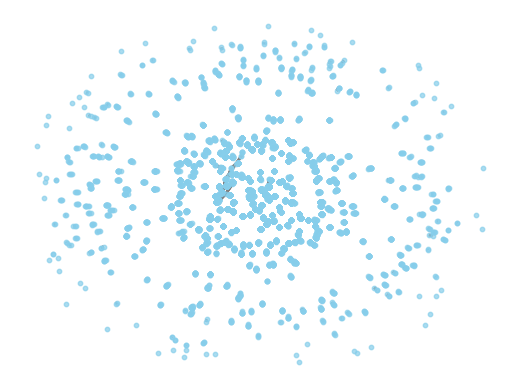

In [227]:
# Draw the nodes
pos = nx.spring_layout(G)  # Define the layout of the nodes
nx.draw_networkx_nodes(G, pos, node_size=10, node_color='skyblue', alpha=0.7)

# Draw the edges
nx.draw_networkx_edges(G, pos, width=2, alpha=1, edge_color='gray')

# Display the graph
plt.axis('off')  # Turn off axis
plt.show()

In [247]:
cpm

,Conflict Id,mine_id
0,24,2
1,42,8
2,57,8
3,76,7
4,90,5
...,...,...
689,6332,14
690,6335,8
691,6371,1
692,6376,1


In [238]:
polyn = copy.deepcopy(poly).set_index('row.id')

In [248]:
gr

,row.id,conflicts
0,73,1
1,74,1
2,75,1
3,76,1
4,77,1
...,...,...
10036,81423,6
10037,81430,1
10038,81431,1
10039,81432,1


In [249]:
j = polyn.merge(gr, how='left', on='row.id')

In [251]:
j.conflicts = j.conflicts.fillna(0)

In [252]:
type(j)

geopandas.geodataframe.GeoDataFrame

In [256]:
j[j.conflicts !=0].shape

(10041, 7)

In [260]:
j.set_geometry('geometry')

,row.id,area,admin,adm0_a3,list_of_commodities,geometry,conflicts
0,1,0.038096,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",0.0
1,2,0.114247,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.28440 -42.43580, 171.28290...",0.0
2,3,0.125528,New Zealand,NZL,"Molybdenum,Tin,Silver,Gold","MULTIPOLYGON (((170.87480 -42.85890, 170.87220...",0.0
3,4,0.288590,New Zealand,NZL,Coal,"MULTIPOLYGON (((168.00960 -45.95730, 168.00900...",0.0
4,5,0.349819,New Zealand,NZL,Coal,"MULTIPOLYGON (((167.88650 -45.89680, 167.88620...",0.0
...,...,...,...,...,...,...,...
81557,81558,0.055417,China,CHN,None,"MULTIPOLYGON (((110.92507 41.11132, 110.92504 ...",0.0
81558,81559,0.034229,China,CHN,None,"MULTIPOLYGON (((110.91125 41.10848, 110.91125 ...",0.0
81559,81560,0.031565,China,CHN,None,"MULTIPOLYGON (((110.91224 41.10593, 110.91222 ...",0.0
81560,81561,0.062556,China,CHN,None,"MULTIPOLYGON (((109.65832 41.28847, 109.65828 ...",0.0


In [280]:
jind = j.set_index('row.id')

In [285]:
jind.to_file('data/interm/mine_con_50.gpkg', driver ='GPKG', engine='fiona')

In [337]:

from shapely.geometry import box

def grid_shape_constructor(resolution =1, min_long=-180, min_lat=-90, max_lon=180, max_lat=90):
    
    
    # Generate grid cells using list comprehensions
    grid_cells = [box(lon, lat, lon + resolution, lat + resolution)
                for lon in range(min_lon, max_lon, resolution)
                for lat in range(min_lat, max_lat, resolution)]

    # Create a GeoDataFrame from the grid cells

    grid = gpd.GeoDataFrame(geometry=grid_cells, crs='EPSG:4326')
    grid['id'] = np.arange(0,grid.shape[0])

    return grid

# Plot the grid
# grid_gdf.plot(facecolor='None', edgecolor='grey', linewidth=.1)


In [305]:
df= gpd.read_file('data/interm/mine_con_50.gpkg')

C:\Users\admin\AppData\Local\Temp\ipykernel_11232\1539893080.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df.area.hist(log = True)


<Axes: >

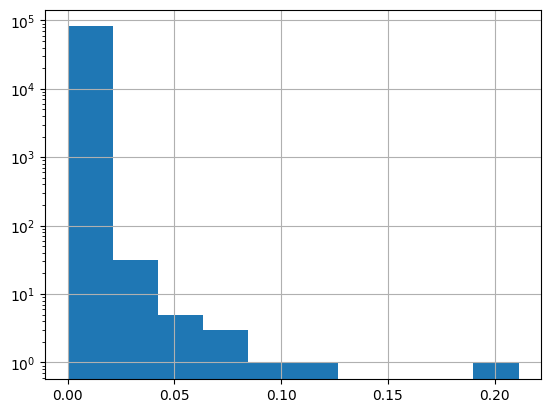

In [380]:
df.area.hist(log = True)

In [338]:
grid = grid_shape_constructor()

In [339]:
grid.head()

,geometry,id
0,"POLYGON ((-179.00000 -90.00000, -179.00000 -89...",0
1,"POLYGON ((-179.00000 -89.00000, -179.00000 -88...",1
2,"POLYGON ((-179.00000 -88.00000, -179.00000 -87...",2
3,"POLYGON ((-179.00000 -87.00000, -179.00000 -86...",3
4,"POLYGON ((-179.00000 -86.00000, -179.00000 -85...",4


In [342]:
jgr = grid.sjoin(df)

In [344]:
gr = jgr.groupby('id')[['area', 'conflicts']].sum().reset_index()

In [383]:
gr.area.describe()

count    4541.000000
mean       34.052237
std       124.358421
min         0.002733
25%         0.937177
50%         4.626202
75%        20.886341
max      2548.993896
Name: area, dtype: float64

In [393]:
gr.shape[0]

4541

In [394]:
grid.shape[0]

64800

In [411]:
jplot = grid.merge(gr, on='id')

In [412]:
jplot['con_dens'] = jplot['conflicts'] / jplot['area']

In [424]:
df.head

<bound method NDFrame.head of        row.id      area        admin adm0_a3  \
0           1  0.038096  New Zealand     NZL   
1           2  0.114247  New Zealand     NZL   
2           3  0.125528  New Zealand     NZL   
3           4  0.288590  New Zealand     NZL   
4           5  0.349819  New Zealand     NZL   
...       ...       ...          ...     ...   
81557   81558  0.055417        China     CHN   
81558   81559  0.034229        China     CHN   
81559   81560  0.031565        China     CHN   
81560   81561  0.062556        China     CHN   
81561   81562  0.004362        China     CHN   

                                     list_of_commodities  conflicts  \
0      Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...        0.0   
1      Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...        0.0   
2                             Molybdenum,Tin,Silver,Gold        0.0   
3                                                   Coal        0.0   
4                                     

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\plotting.py:777: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


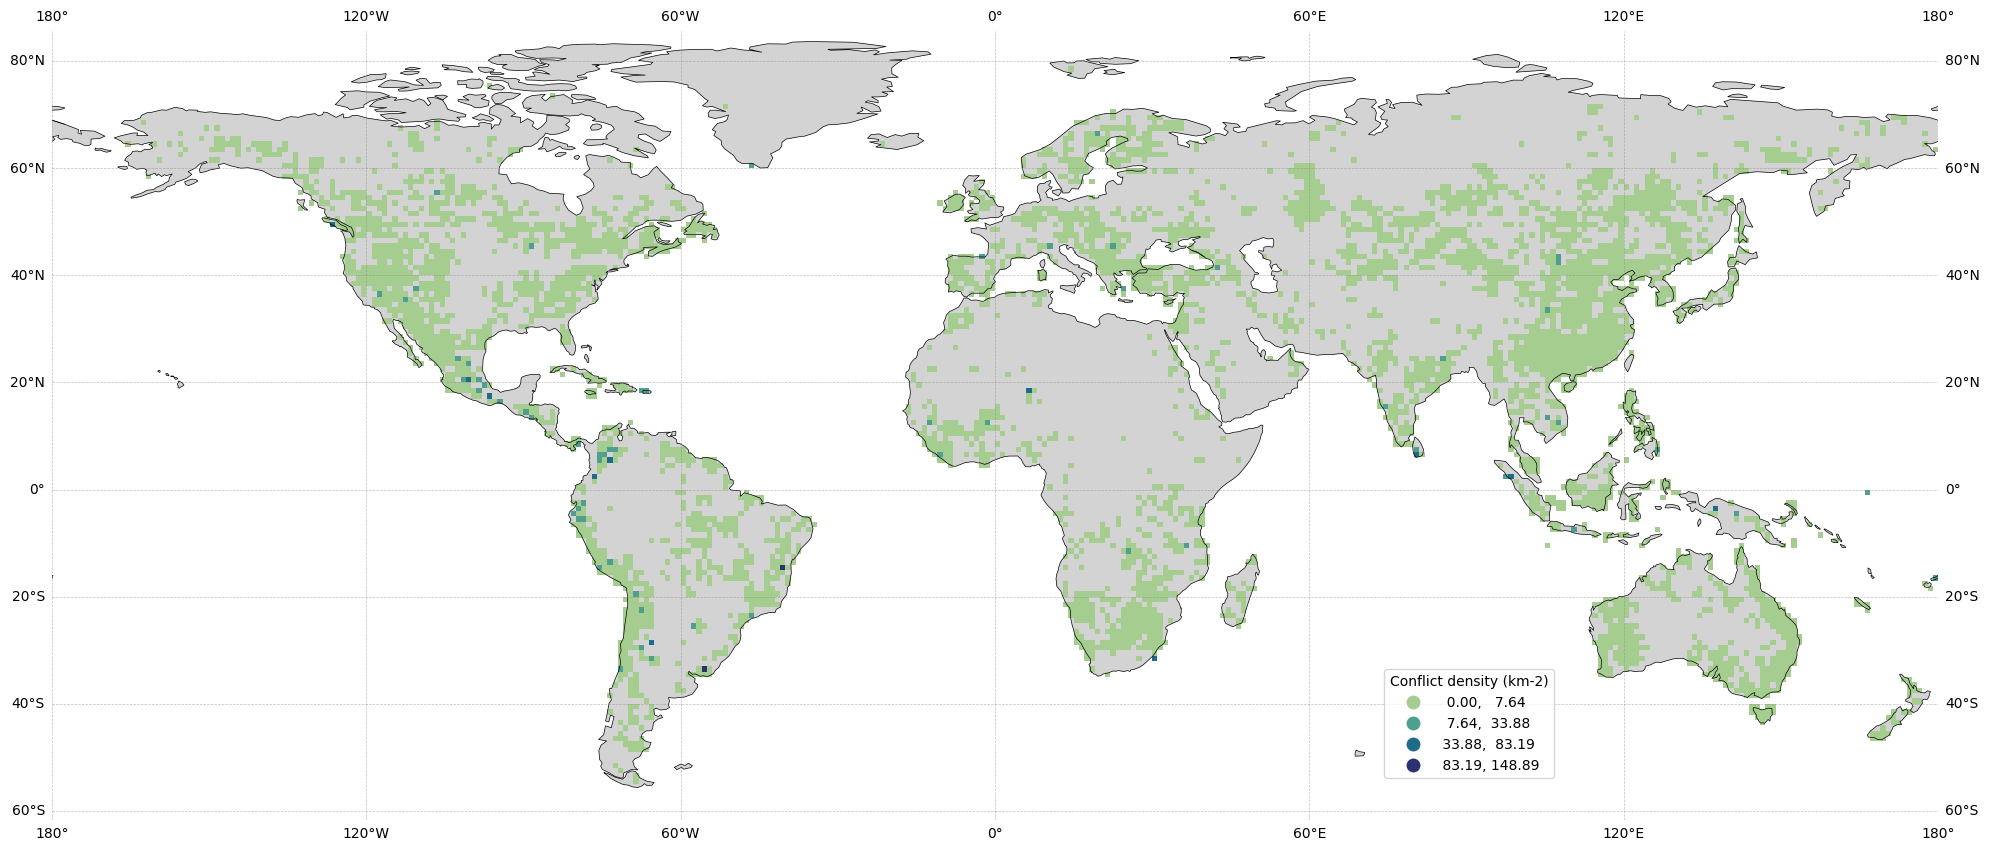

In [453]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create a figure and axis with a specified projection
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the GeoDataFrame
jplot.plot(column='con_dens', scheme='fisherjenks', k=4, legend=True, cmap='crest', ax=ax, transform=ccrs.PlateCarree())

# Add coastlines and land features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Customize gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

#divider = make_axes_locatable(ax)
#cax = divider.append_axes("right", size="5%", pad=0.1)
legend = ax.get_legend()
legend.set_bbox_to_anchor((.8, 0.2))  # Move legend outside the plot
legend.set_title('Conflict density (km-2)')
#fig.colorbar(legend, cax=cax)

ax.set_axis_off()

# Show the plot
plt.tight_layout()  # Adjust layout to prevent overlap

plt.savefig('fig/conflit_density_global.png')
plt.show()


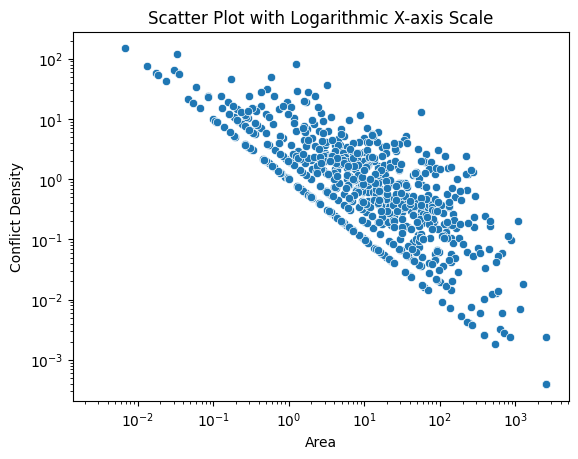

In [473]:
sns.scatterplot(x=jplot['area'], y=jplot['con_dens'])

plt.xscale('log')
plt.yscale('log')

# Set labels and title
plt.xlabel('Area')
plt.ylabel('Conflict Density')
plt.title('Scatter Plot with Logarithmic X-axis Scale')

# Show the plot
plt.show()

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


<Axes: xlabel='con_dens', ylabel='Count'>

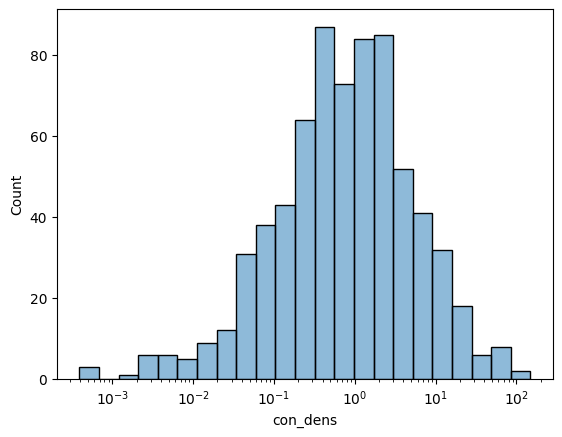

In [478]:
sns.histplot(jplot['con_dens'],  log_scale=True, kde=True)